<a href="https://colab.research.google.com/github/aminsiddik2810/data-science-2026/blob/https%2Fgithub.com%2Faminsiddik2810%2Fdata-science-2026.git/Pertemuan_7_AminSiddikRangkuti_220401010124.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Library berhasil diimport")

Library berhasil diimport


In [20]:
np.random.seed(42)

jumlah_data = 200
pengalaman = np.random.uniform(0, 15, jumlah_data)
gaji = 3.5 + 2.1 * pengalaman + np.random.normal(0, 1.5, jumlah_data)

df = pd.DataFrame({
    "Pengalaman_Tahun": pengalaman,
    "Gaji_Juta": gaji
})

df.head()

,Pengalaman_Tahun,Gaji_Juta
0,5.618102,14.277977
1,14.260715,33.795881
2,10.979909,26.997418
3,8.979877,21.286215
4,2.340280,11.213249


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Pengalaman_Tahun  200 non-null    float64
 1   Gaji_Juta         200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [22]:
df.describe()

,Pengalaman_Tahun,Gaji_Juta
count,200.000000,200.000000
mean,7.260093,18.847318
std,4.423371,9.367940
min,0.082832,2.409377
25%,3.428736,10.442161
50%,7.417294,18.269076
75%,11.352894,27.075815
max,14.803304,36.464487


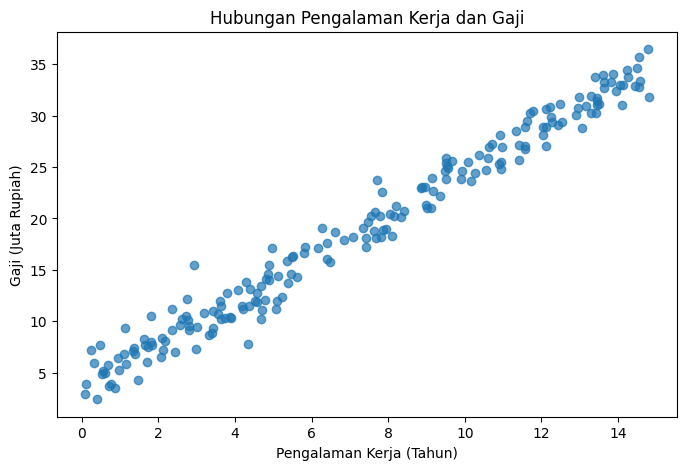

In [23]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Pengalaman_Tahun"], df["Gaji_Juta"], alpha=0.7)
plt.xlabel("Pengalaman Kerja (Tahun)")
plt.ylabel("Gaji (Juta Rupiah)")
plt.title("Hubungan Pengalaman Kerja dan Gaji")
plt.show()

In [24]:
korelasi = df.corr(numeric_only=True)
korelasi

,Pengalaman_Tahun,Gaji_Juta
Pengalaman_Tahun,1.000000,0.987896
Gaji_Juta,0.987896,1.000000


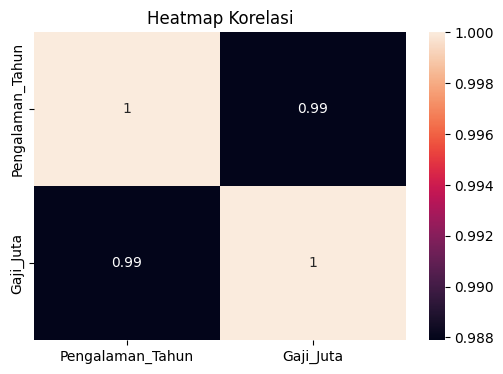

In [25]:
plt.figure(figsize=(6, 4))
sns.heatmap(korelasi, annot=True)
plt.title("Heatmap Korelasi")
plt.show()

In [26]:
X = df[["Pengalaman_Tahun"]]
y = df["Gaji_Juta"]

print("Ukuran X:", X.shape)
print("Ukuran y:", y.shape)

Ukuran X: (200, 1)
Ukuran y: (200,)


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Jumlah data training:", X_train.shape[0])
print("Jumlah data testing:", X_test.shape[0])

Jumlah data training: 160
Jumlah data testing: 40


In [28]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Contoh data setelah scaling:")
print(X_train_scaled[:5])

Contoh data setelah scaling:
[[-1.2447074 ]
 [ 1.41234564]
 [ 0.68833608]
 [-0.08766153]
 [-0.55723487]]


In [29]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("Model berhasil dilatih")
print("Intercept (β0):", round(model.intercept_, 3))
print("Koefisien/Slope (β1):", round(model.coef_[0], 3))

Model berhasil dilatih
Intercept (β0): 18.776
Koefisien/Slope (β1): 9.308


In [30]:
y_pred = model.predict(X_test_scaled)

hasil_prediksi = pd.DataFrame({
    "Gaji_Aktual": y_test.values,
    "Gaji_Prediksi": y_pred,
    "Residual": y_test.values - y_pred
})

hasil_prediksi.head(10)

,Gaji_Aktual,Gaji_Prediksi,Residual
0,18.074567,19.153920,-1.079353
1,12.122432,9.327853,2.794579
2,21.031324,22.754887,-1.723563
3,10.659061,11.044711,-0.385650
4,3.889268,3.741890,0.147378
5,28.805797,31.109682,-2.303886
6,31.786041,34.763740,-2.977700
7,23.615946,24.971498,-1.355552
8,25.560109,23.946077,1.614033
9,24.600040,24.495311,0.104729


In [31]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE  :", round(mae, 3))
print("MSE  :", round(mse, 3))
print("RMSE :", round(rmse, 3))
print("R²   :", round(r2, 3))

MAE  : 1.258
MSE  : 2.44
RMSE : 1.562
R²   : 0.97


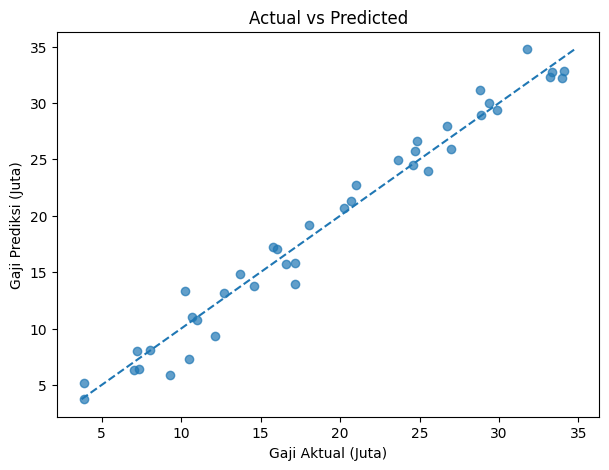

In [32]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.7)

nilai_min = min(y_test.min(), y_pred.min())
nilai_max = max(y_test.max(), y_pred.max())

plt.plot([nilai_min, nilai_max], [nilai_min, nilai_max], linestyle="--")
plt.xlabel("Gaji Aktual (Juta)")
plt.ylabel("Gaji Prediksi (Juta)")
plt.title("Actual vs Predicted")
plt.show()

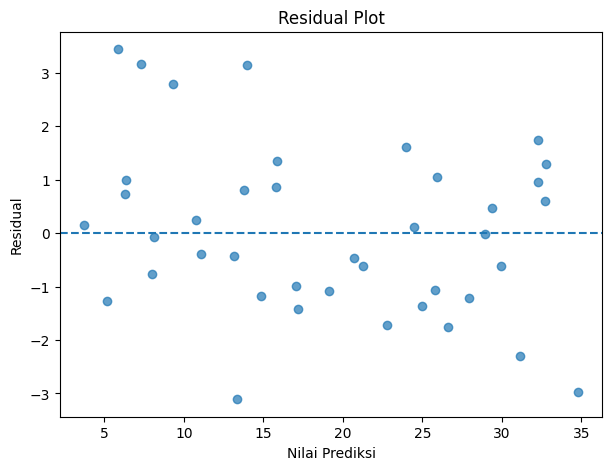

In [33]:
residual = y_test - y_pred

plt.figure(figsize=(7, 5))
plt.scatter(y_pred, residual, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.xlabel("Nilai Prediksi")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

In [34]:
data_baru = pd.DataFrame({
    "Pengalaman_Tahun": [1, 3, 5, 10, 15]
})

data_baru_scaled = scaler.transform(data_baru)
prediksi_gaji_baru = model.predict(data_baru_scaled)

hasil_baru = pd.DataFrame({
    "Pengalaman_Tahun": data_baru["Pengalaman_Tahun"],
    "Prediksi_Gaji_Juta": prediksi_gaji_baru
})

hasil_baru

,Pengalaman_Tahun,Prediksi_Gaji_Juta
0,1,5.632276
1,3,9.853217
2,5,14.074158
3,10,24.626509
4,15,35.178861
